In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Set Correct Paths**

In [2]:
from pathlib import Path

DATA_ROOT = Path("/content/drive/MyDrive/content/sr_project")

HR_DIR = DATA_ROOT / "HR_256"
LR_DIR = DATA_ROOT / "LR_x4"

print("HR_DIR:", HR_DIR)
print("LR_DIR:", LR_DIR)

assert HR_DIR.exists(), "HR_256 folder not found!"
assert LR_DIR.exists(), "LR_x4 folder not found!"

HR_DIR: /content/drive/MyDrive/content/sr_project/HR_256
LR_DIR: /content/drive/MyDrive/content/sr_project/LR_x4


# **Define Train/Test IDs**

In [3]:
def make_ids(start, end):
    return [f"{i:04d}" for i in range(start, end+1)]

train_ids = make_ids(0, 99)
test_ids  = make_ids(100, 109)

print("Train:", train_ids[:3], "...", train_ids[-3:])
print("Test:", test_ids)

Train: ['0000', '0001', '0002'] ... ['0097', '0098', '0099']
Test: ['0100', '0101', '0102', '0103', '0104', '0105', '0106', '0107', '0108', '0109']


# **Dataset Class (Patch Training)**

In [11]:
from pathlib import Path
from PIL import Image
import torchvision.transforms.functional as TF
import random
import torch
from torch.utils.data import Dataset

def find_img(folder: Path, id_: str):
    for ext in [".png", ".jpg", ".jpeg"]:
        p = folder / f"{id_}{ext}"
        if p.exists():
            return p
    raise FileNotFoundError(f"Missing file for id={id_} in {folder}")

class SRDataset(Dataset):
    def __init__(self, lr_dir, hr_dir, ids, scale=4, patch_size=24, augment=True):
        self.lr_dir = Path(lr_dir)
        self.hr_dir = Path(hr_dir)
        self.ids = ids
        self.scale = scale
        self.patch_size = patch_size
        self.augment = augment

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        id_ = self.ids[idx]

        lr_path = find_img(self.lr_dir, id_)
        hr_path = find_img(self.hr_dir, id_)

        lr = TF.to_tensor(Image.open(lr_path).convert("RGB"))
        hr = TF.to_tensor(Image.open(hr_path).convert("RGB"))

        _, h, w = lr.shape
        p = self.patch_size
        s = self.scale

        top = random.randint(0, h - p)
        left = random.randint(0, w - p)

        lr_patch = lr[:, top:top+p, left:left+p]
        hr_patch = hr[:, top*s:(top+p)*s, left*s:(left+p)*s]

        if self.augment:
            if random.random() < 0.5:
                lr_patch = TF.hflip(lr_patch)
                hr_patch = TF.hflip(hr_patch)
            if random.random() < 0.5:
                lr_patch = TF.vflip(lr_patch)
                hr_patch = TF.vflip(hr_patch)

        return lr_patch, hr_patch

# **Dataloaders**

In [12]:
train_dataset = SRDataset(LR_DIR, HR_DIR, train_ids, patch_size=24)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print("Train batches:", len(train_loader))

Train batches: 4


# **ESPCN Model (×4)**

In [13]:
import torch.nn as nn

class ESPCN(nn.Module):
    def __init__(self, scale=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 5, padding=2),
            nn.ReLU(True),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(32, 3*(scale**2), 3, padding=1),
            nn.PixelShuffle(scale)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ESPCN().to(device)

# **Train Model**

In [14]:
import torch.optim as optim

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for lr_patch, hr_patch in train_loader:
        lr_patch = lr_patch.to(device)
        hr_patch = hr_patch.to(device)

        sr = model(lr_patch)
        loss = criterion(sr, hr_patch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/50  Loss: 0.4956
Epoch 2/50  Loss: 0.5102
Epoch 3/50  Loss: 0.4857
Epoch 4/50  Loss: 0.4678
Epoch 5/50  Loss: 0.4260
Epoch 6/50  Loss: 0.4368
Epoch 7/50  Loss: 0.3843
Epoch 8/50  Loss: 0.3954
Epoch 9/50  Loss: 0.3481
Epoch 10/50  Loss: 0.3122
Epoch 11/50  Loss: 0.2761
Epoch 12/50  Loss: 0.2453
Epoch 13/50  Loss: 0.2278
Epoch 14/50  Loss: 0.2114
Epoch 15/50  Loss: 0.1880
Epoch 16/50  Loss: 0.1905
Epoch 17/50  Loss: 0.1722
Epoch 18/50  Loss: 0.1707
Epoch 19/50  Loss: 0.1653
Epoch 20/50  Loss: 0.1586
Epoch 21/50  Loss: 0.1607
Epoch 22/50  Loss: 0.1609
Epoch 23/50  Loss: 0.1507
Epoch 24/50  Loss: 0.1552
Epoch 25/50  Loss: 0.1553
Epoch 26/50  Loss: 0.1360
Epoch 27/50  Loss: 0.1437
Epoch 28/50  Loss: 0.1322
Epoch 29/50  Loss: 0.1416
Epoch 30/50  Loss: 0.1352
Epoch 31/50  Loss: 0.1391
Epoch 32/50  Loss: 0.1235
Epoch 33/50  Loss: 0.1236
Epoch 34/50  Loss: 0.1266
Epoch 35/50  Loss: 0.1309
Epoch 36/50  Loss: 0.1203
Epoch 37/50  Loss: 0.1210
Epoch 38/50  Loss: 0.1182
Epoch 39/50  Loss: 0.

# **Evaluate on Test Images**

In [17]:
import torch.nn.functional as F
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF

def find_img(folder: Path, id_: str):
    for ext in [".png", ".jpg", ".jpeg"]:
        p = folder / f"{id_}{ext}"
        if p.exists():
            return p
    raise FileNotFoundError(f"Missing file for id={id_} in {folder}")

def psnr(sr, hr):
    mse = F.mse_loss(sr, hr)
    return 10 * torch.log10(1.0 / mse)

model.eval()
psnr_list = []

with torch.no_grad():
    for id_ in test_ids:
        lr_path = find_img(LR_DIR, id_)
        hr_path = find_img(HR_DIR, id_)

        lr = TF.to_tensor(Image.open(lr_path).convert("RGB")).unsqueeze(0).to(device)
        hr = TF.to_tensor(Image.open(hr_path).convert("RGB")).unsqueeze(0).to(device)

        sr = model(lr).clamp(0, 1)

        p = psnr(sr, hr)
        psnr_list.append(p.item())

print("Average Test PSNR:", np.mean(psnr_list))

Average Test PSNR: 18.823040390014647


# **Comparison images (LR-up / Bicubic / ESPCN / HR)**

In [23]:
import torch
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from pathlib import Path

# Reuse find_img
def find_img(folder: Path, id_: str):
    for ext in [".png", ".jpg", ".jpeg"]:
        p = folder / f"{id_}{ext}"
        if p.exists():
            return p
    raise FileNotFoundError(f"Missing file for id={id_} in {folder}")

# Output folder
OUT_DIR = Path("/content/sr_compare")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def bicubic_up(lr_tensor, scale=4):
    return F.interpolate(lr_tensor, scale_factor=scale, mode="bicubic", align_corners=False).clamp(0,1)

def save_compare_for_id(id_):
    lr_path = find_img(LR_DIR, id_)
    hr_path = find_img(HR_DIR, id_)

    lr = TF.to_tensor(Image.open(lr_path).convert("RGB")).unsqueeze(0).to(device)
    hr = TF.to_tensor(Image.open(hr_path).convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        sr = model(lr).clamp(0,1)
        bic = bicubic_up(lr, scale=4)
        lr_view = bic  # LR upscaled just for viewing

    # Convert to PIL
    lr_view_pil = TF.to_pil_image(lr_view.squeeze(0).cpu())
    bic_pil     = TF.to_pil_image(bic.squeeze(0).cpu())
    sr_pil      = TF.to_pil_image(sr.squeeze(0).cpu())
    hr_pil      = TF.to_pil_image(hr.squeeze(0).cpu())

    # Save individual images
    lr_view_pil.save(OUT_DIR / f"{id_}_LRup.png")
    bic_pil.save(OUT_DIR / f"{id_}_Bicubic.png")
    sr_pil.save(OUT_DIR / f"{id_}_ESPCN.png")
    hr_pil.save(OUT_DIR / f"{id_}_HR.png")

    # Save one 2x2 grid image
    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(2,2,1); ax.imshow(lr_view_pil); ax.set_title("LR (upsampled)"); ax.axis("off")
    ax = fig.add_subplot(2,2,2); ax.imshow(bic_pil);     ax.set_title("Bicubic");       ax.axis("off")
    ax = fig.add_subplot(2,2,3); ax.imshow(sr_pil);      ax.set_title("ESPCN");         ax.axis("off")
    ax = fig.add_subplot(2,2,4); ax.imshow(hr_pil);      ax.set_title("HR (Ground Truth)"); ax.axis("off")
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{id_}_COMPARE.png", dpi=150)
    plt.close(fig)

# Save comparisons for all test images
for id_ in test_ids:
    save_compare_for_id(id_)

print("✅ Saved comparison images to:", OUT_DIR)

✅ Saved comparison images to: /content/sr_compare


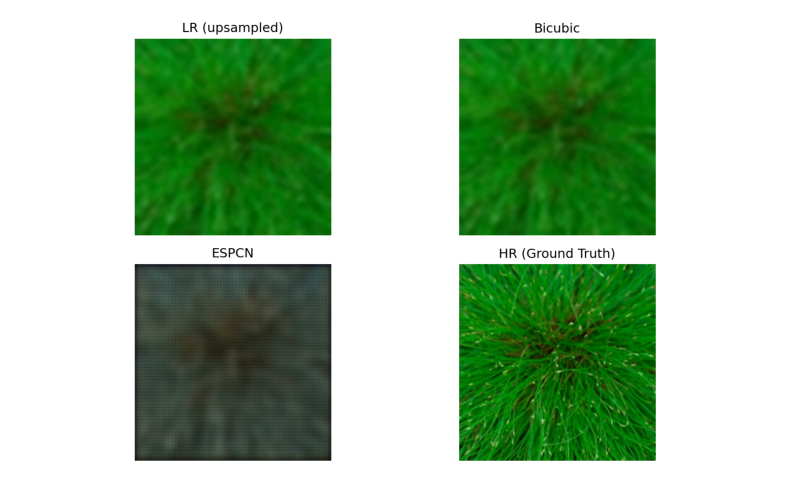

In [24]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

show_id = test_ids[0]  # or "0100"
img = Image.open(Path("/content/sr_compare") / f"{show_id}_COMPARE.png")

plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis("off")
plt.show()

Test

In [18]:
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
from pathlib import Path

def find_img(folder: Path, id_: str):
    for ext in [".png", ".jpg", ".jpeg"]:
        p = folder / f"{id_}{ext}"
        if p.exists():
            return p
    raise FileNotFoundError(f"Missing file for id={id_} in {folder}")

def bicubic_up(x, scale=4):
    return F.interpolate(x, scale_factor=scale, mode="bicubic", align_corners=False).clamp(0,1)

def psnr(sr, hr):
    mse = F.mse_loss(sr, hr)
    return 10 * torch.log10(1.0 / mse)

bic_psnrs = []
with torch.no_grad():
    for id_ in test_ids:
        lr = TF.to_tensor(Image.open(find_img(LR_DIR, id_)).convert("RGB")).unsqueeze(0).to(device)
        hr = TF.to_tensor(Image.open(find_img(HR_DIR, id_)).convert("RGB")).unsqueeze(0).to(device)
        bic = bicubic_up(lr, 4)
        bic_psnrs.append(psnr(bic, hr).item())

print("Bicubic Test PSNR:", float(np.mean(bic_psnrs)))

Bicubic Test PSNR: 23.051351928710936


In [19]:
from PIL import Image

for id_ in ["0100","0101","0102","0103"]:
    lr_path = find_img(LR_DIR, id_)
    hr_path = find_img(HR_DIR, id_)
    lr = Image.open(lr_path)
    hr = Image.open(hr_path)
    print(id_, "LR:", lr.size, "HR:", hr.size, "|", lr_path.name, hr_path.name)

0100 LR: (64, 64) HR: (256, 256) | 0100.jpg 0100.jpg
0101 LR: (64, 64) HR: (256, 256) | 0101.jpg 0101.jpg
0102 LR: (64, 64) HR: (256, 256) | 0102.jpg 0102.jpg
0103 LR: (64, 64) HR: (256, 256) | 0103.jpg 0103.jpg


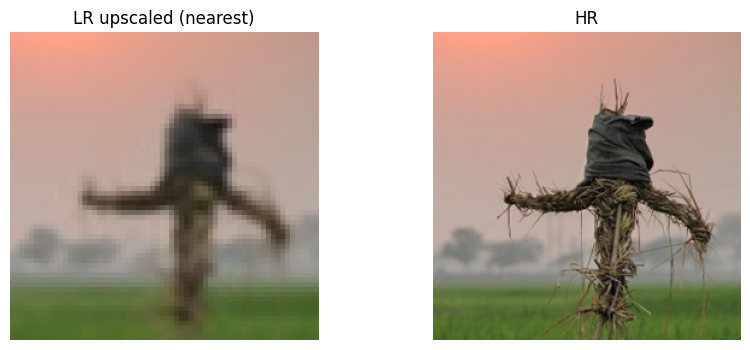

In [22]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

id_ = "0101"
lr = TF.to_tensor(Image.open(find_img(LR_DIR, id_)).convert("RGB")).unsqueeze(0).to(device)
hr = TF.to_tensor(Image.open(find_img(HR_DIR, id_)).convert("RGB")).unsqueeze(0).to(device)

lr_up = F.interpolate(lr, scale_factor=4, mode="nearest")
hr_cpu = hr.squeeze(0).cpu()
lr_up_cpu = lr_up.squeeze(0).cpu()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(TF.to_pil_image(lr_up_cpu)); plt.title("LR upscaled (nearest)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(TF.to_pil_image(hr_cpu)); plt.title("HR"); plt.axis("off")
plt.show()